# Assignment 3: Linear Models

# Pavi Gupta, tgz5gw

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1. A model is linear when the input features, or independent variables, are expressed as a linear combination to create an output, or the dependent variable. Linear in this context means that a change in the input would make a constant, proportional change in the output. A linear model implies that it is a straight line.

2. The purpose of the intercept is to give a baseline value of the predicted values. The intercept occurs when X = 0. The intercept can be interpreted if X can equal 0 both in the model and realistically. For example, if X represents the number of minutes spent studying, and X=0, the Y value, is directly affected by that. If X never equals 0 in the model, it represents a theoretical starting point instead of something realistic. 

3. Linear regression can be used for classification. It would be used for binary classification, or assigning 0s and 1s. However, classification can be difficult in particular cases, such as scaling to a variety of classes, that can't be done in the black-and-white manner that classification requires. 

4. A sign that the linear model is over-fitting that the training performance is extremely high and accurate, but the test accuracy is low. Another is if the coefficients are very large and the target variable is small. Over-fitted models are also extremely sensitive to small data changes. 

5. The purpose of two-stage least squares is to solve the problem when the X variable gets correlated with the error term. The framework breaks regression into two stages: first regress X on the instrumental variable, Z, and calculate the predicted values. Next, regress the Y on the predicted values found previously. Multicollinearity is when two or more variables that are independent are highly correlated. It exists in two-stage least squares when the instrumental variable Z is barely correlated with X, or there are multiple Zs that are very correlated with each other. Multicollinearity also negatively affects two-stage least sqaures when the predicted values are highly correlated with the control variable(s). 

6. Nonlinear relationships can be incorporated into the analysis between x and y by using polynominal regression to capture the pattern. We can add an x^2 or x^3 to the linear regression formula. 

7. The slope coefficient in a linear regression can be interpreted as the the increase of the independent variable by one unit with the average change in the dependent variable. The direction of the slope coefficient is indicated by the sign in front of the number. 

8. The train/test split is when the dataset is randomized and split into a training set and test set. The model first learns from the training data, and once complete, the test set is used to test the accuracy of the model. The purpose of this is to see how to model would perform with other real-world data. It is quick and easy to do, and useful for large datasets. However, if the data is not split properly, even if it's by chance, it will mess up the model's performance. K-fold cross-validation splits the data into k equal segments/folds, trains the model k time, and each time it is trained another fold serves as the test set. This is a more repetitive method of the train/test split, uses all the data, and it reliable. However, it can be expensive to use this method. 

9. Finding the value of 'k' in the k-fold is affected by the size of the data set, how much money it costs, and the trade-off between bias and variance. Usually, k is kept at 5 or 10. 

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [59]:
# Question 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

df = pd.read_csv('./data/Q1_clean.csv')
df = df.rename(columns={'Neighbourhood ': 'Neighbourhood'})
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [60]:
avg_stats = df.groupby('Neighbourhood').agg({
    'Price': 'mean', 
    'Review Scores Rating': 'mean'
}).reset_index()

print("Average Stats by Neighbourhood:")
print(avg_stats)

most_expensive = avg_stats.loc[avg_stats['Price'].idxmax()]
print(f"\nMost expensive borough: {most_expensive['Neighbourhood']} (${most_expensive['Price']:.2f})")

Average Stats by Neighbourhood:
   Neighbourhood       Price  Review Scores Rating
0          Bronx   75.276498             91.654378
1       Brooklyn  127.747378             92.363497
2      Manhattan  183.664286             91.801496
3         Queens   96.857233             91.549057
4  Staten Island  146.166667             90.843750

Most expensive borough: Manhattan ($183.66)


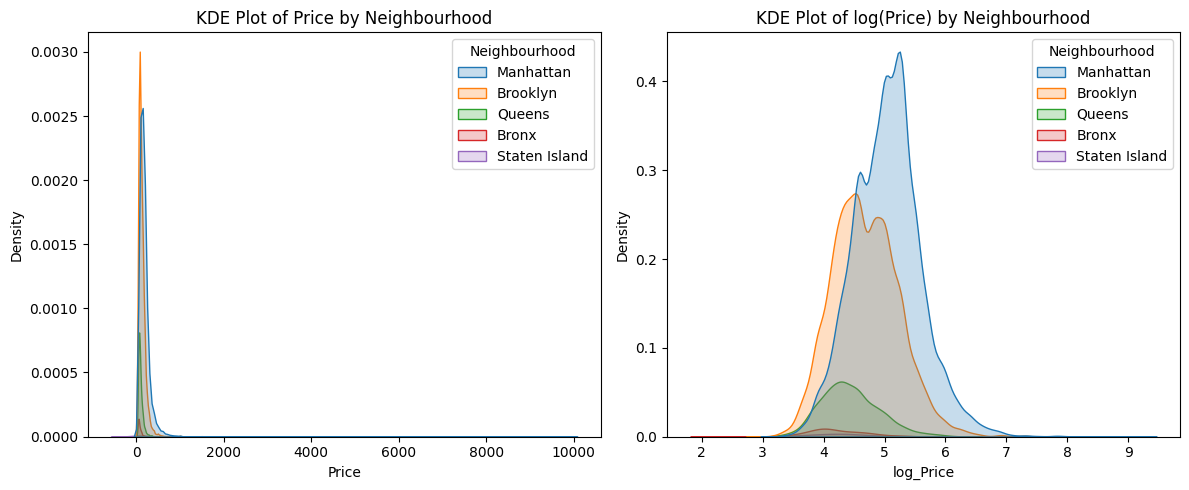

In [61]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='Price', hue='Neighbourhood', fill=True)
plt.title('KDE Plot of Price by Neighbourhood')

df['log_Price'] = np.log(df['Price'])
plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='log_Price', hue='Neighbourhood', fill=True)
plt.title('KDE Plot of log(Price) by Neighbourhood')

plt.tight_layout()
plt.show()

In [62]:
# Question 2

X = pd.get_dummies(df['Neighbourhood'], drop_first=True)
y = df['Price']

model = LinearRegression()
model.fit(X, y)

print('Intercept:', model.intercept_)
coef_table = pd.Series(model.coef_, index=X.columns)
print(coef_table)

Intercept: 75.27649769584667
Brooklyn          52.470881
Manhattan        108.387789
Queens            21.580735
Staten Island     70.890169
dtype: float64


I am dropping the first category. Because of this, the intercept is the average price in the Bronx. Each coefficient equals the differences between the borough's mean price and the Bronx's mean price. Conditional group means and estimated coefficients are related because the coefficients directly correspong with the differences between the conditional group.

In [63]:
# Question 3

X = df[['Review Scores Rating']]
y = df['Price']

model = LinearRegression()
model.fit(X, y)

print('Intercept:', model.intercept_)
print('Slope:', model.coef_[0])

Intercept: 60.878390657123816
Slope: 1.0208266022674735


Slope coefficient: Every one point increase in the review score rating increases the predicted price per night by an average of 1.02.

In [64]:
# Question 4
dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True)

X = pd.concat([df[['Review Scores Rating']], dummies], axis=1)
y = df['Price']

model = LinearRegression()
model.fit(X, y)

print('Intercept:', model.intercept_)
print('Slope:', model.coef_[0])
coef_table = pd.Series(model.coef_, index=X.columns)
print(coef_table)

Intercept: -23.812561011673182
Slope: 1.0811164834598528
Review Scores Rating      1.081116
Brooklyn                 51.704240
Manhattan               108.228737
Queens                   21.694600
Staten Island            71.766552
dtype: float64


The slope changed from 1.02 to 1.08, making it just a little steeper. The neighborhood averages are extremely similar to the price regression, with just a little bit of variation. 

In [65]:
# Question 5

dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True)

interactions = dummies.mul(df['Review Scores Rating'], axis=0)
interactions.columns = [col + '_interaction' for col in dummies.columns]

X = pd.concat([df[['Review Scores Rating']], dummies, interactions], axis=1)
y = df['Price']

model = LinearRegression()
model.fit(X, y)

coef_table = pd.Series(model.coef_, index=X.columns)
print(coef_table)

Review Scores Rating            0.574311
Brooklyn                      -16.392990
Manhattan                      41.315429
Queens                         28.259701
Staten Island                2963.071040
Brooklyn_interaction            0.741165
Manhattan_interaction           0.729703
Queens_interaction             -0.072294
Staten Island_interaction     -31.831748
dtype: float64


In [66]:
base_slope = coef_table['Review Scores Rating']

slopes = {}
slopes['Bronx'] = base_slope

for col in dummies.columns:
    slopes[col] = base_slope + coef_table[col + '_interaction']

for k, v in slopes.items():
    print(f"{k}: {v}")

Bronx: 0.5743109493637346
Brooklyn: 1.3154762151087418
Manhattan: 1.304014393927329
Queens: 0.5020166039976822
Staten Island: -31.257436624712767


Overall, we can see that the neighborhoods aren't that similar, but Brooklyn and Manhattan are close and Bronx and Queens are also close. Staten Island is completely different with a negative slope. 

In [67]:
# Question 6

X1 = df[['Review Scores Rating']]
y = df['Price']

model = LinearRegression()

cv1 = cross_val_score(model, X1, y, cv=5, scoring='neg_mean_squared_error')
print("Model 1 MSE:", -np.mean(cv1))

dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True)

X2 = pd.concat([df[['Review Scores Rating']], dummies], axis=1)

cv2 = cross_val_score(model, X2, y, cv=5, scoring='neg_mean_squared_error')
print("Model 2 MSE:", -np.mean(cv2))

interactions = dummies.mul(df['Review Scores Rating'], axis=0)
interactions.columns = [col + '_interaction' for col in dummies.columns]

X3 = pd.concat([df[['Review Scores Rating']], dummies, interactions], axis=1)

cv3 = cross_val_score(model, X3, y, cv=5, scoring='neg_mean_squared_error')
print("Model 3 MSE:", -np.mean(cv3))


Model 1 MSE: 22102.830156262135
Model 2 MSE: 21113.112422262097
Model 3 MSE: 21418.246870450363


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


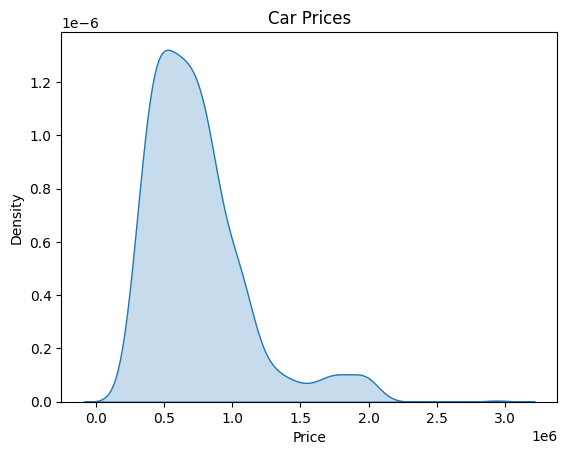

In [68]:
import statsmodels.api as sm
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import PolynomialFeatures
from datetime import datetime

# Question 1
df = pd.read_csv('./data/cars_hw.csv')
print(df['Price'].describe())

sns.kdeplot(df["Price"], fill=True)
plt.title("Car Prices")
plt.show()


In [69]:
df.groupby('Body_Type')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


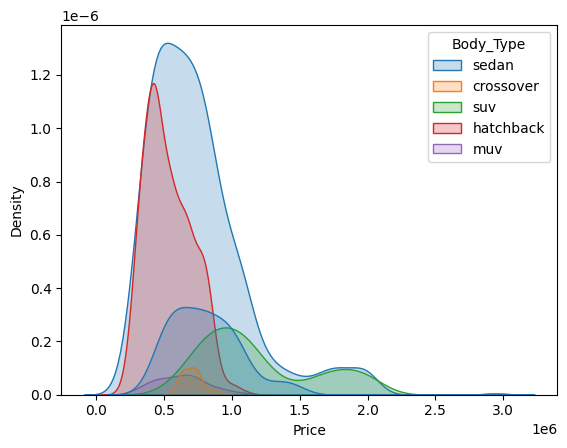

In [70]:
sns.kdeplot(df['Price'], fill=True)
body_summary = df.groupby('Body_Type')['Price'].describe()
sns.kdeplot(data=df, x='Price', hue='Body_Type', fill=True)
plt.savefig('grouped_price_kde.png')

The most expensive car type are SUVs and they have the most variance.

In [71]:
# Question 2

X = sm.add_constant(df['Seating_Capacity'])
model_lin = sm.OLS(df['Price'], X).fit()
print(f"Slope: {model_lin.params['Seating_Capacity']}")

X_cat = pd.get_dummies(df['Seating_Capacity'].astype(str), drop_first=True).astype(float)
model_cat = sm.OLS(df['Price'], sm.add_constant(X_cat)).fit()

Slope: 59267.99803672188


The slope coefficient is about 59267. For an increase in a seat in a car by 1, the price increases by $59267.

In [72]:
X_cat = pd.get_dummies(df['Seating_Capacity'], drop_first=True)
y = df['Price']
model_cat = LinearRegression()
model_cat.fit(X_cat, y)

coef_table = pd.Series(model_cat.coef_, index=X_cat.columns)
print(coef_table)

5    5.464839e+05
6    1.456000e+06
7    7.359487e+05
8    2.718000e+05
dtype: float64


The differences in price are not roughly linear to the number of seats. These numbers show us that there is no consistent increase.

In [73]:
# Question 3
df['Age'] = datetime.now().year - df['Make_Year']
cv = KFold(n_splits=10, shuffle=True, random_state=42)
mse_scores = []
degrees = range(1, 8)

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_p = poly.fit_transform(df[['Age']])
    scores = cross_val_score(LinearRegression(), X_p, df['Price'], 
                              scoring='neg_mean_squared_error', cv=cv)
    mse_scores.append(-scores.mean())

optimal_degree = degrees[np.argmin(mse_scores)]
for d, err in zip(degrees, mse_scores):
    print(f"Degree {d} MSE = {err}")

Degree 1 MSE = 97377248063.9968
Degree 2 MSE = 97395705968.6351
Degree 3 MSE = 96743204818.44316
Degree 4 MSE = 96225038252.27225
Degree 5 MSE = 95265035515.13638
Degree 6 MSE = 95358958403.08952
Degree 7 MSE = 94688971539.20418


In [74]:
print(f"Optimal polynomial degree: {optimal_degree}")

Optimal polynomial degree: 7


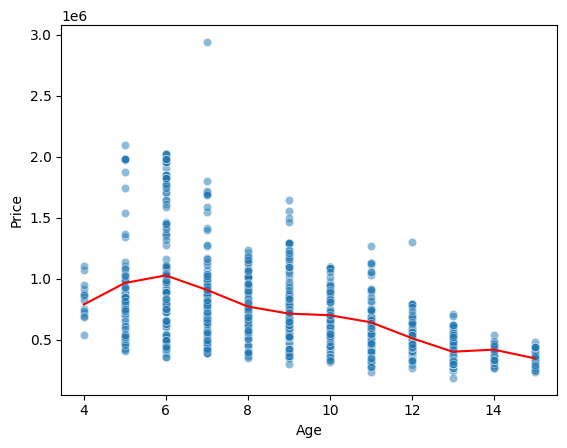

In [75]:
# Question 4
poly_opt = PolynomialFeatures(degree=optimal_degree)
X_poly_opt = poly_opt.fit_transform(df[['Age']])
final_model = LinearRegression().fit(X_poly_opt, df['Price'])
df['Predicted_Price'] = final_model.predict(X_poly_opt)

sns.scatterplot(data=df, x='Age', y='Price', alpha=0.5)
df_sorted = df.sort_values('Age')
plt.plot(df_sorted['Age'], df_sorted['Predicted_Price'], color='red')
plt.show()

The model does accurately fit the patterns in the data.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [76]:
df = pd.read_csv('./data/heart_hw.csv')
df['transplant_num'] = (df['transplant'] == 'treatment').astype(int)
df.head()

,Unnamed: 0,age,transplant,y,transplant_num
0,1,53,control,0,0
1,2,43,control,0,0
2,3,52,control,0,0
3,4,52,control,0,0
4,5,54,control,0,0


In [77]:
# Question 1 
prop_control = df[df['transplant'] == 'control']['y'].mean()
prop_treatment = df[df['transplant'] == 'treatment']['y'].mean()
ate = prop_treatment - prop_control
print("The average treatment effect is:", ate)

The average treatment effect is: 0.23017902813299232


In [78]:
# Question 2

df['treatment_var'] = (df['transplant'] == 'treatment').astype(int)

X = df[['treatment_var']]
y = df['y']

model = LinearRegression()
model.fit(X, y)

intercept = model.intercept_
coef = model.coef_[0]

print('Intercept:', intercept)
print('Transplant coefficient (ATE):', coef)
print('Treatment mean:', intercept + coef)

Intercept: 0.11764705882352941
Transplant coefficient (ATE): 0.23017902813299232
Treatment mean: 0.34782608695652173


The intercept and coefficient are the same as the numbers computed in Part I.

In [79]:
# Question 3

df['treatment_var'] = (df['transplant'] == 'treatment').astype(int)

X = df[['treatment_var', 'age']]
y = df['y']

model = LinearRegression()
model.fit(X, y)

intercept = model.intercept_
beta_treatment = model.coef_[0]
beta_age = model.coef_[1]

print('Intercept:', intercept)
print('Transplant coefficient:', beta_treatment)
print('Age coefficient:', beta_age)

Intercept: 0.7019569721740946
Transplant coefficient: 0.26470168650367487
Age coefficient: -0.013607217160218642


The coefficient of transplant increases a little bit when the control is added. The intercept represents the survival that is predicted when age is 0 and there is no transplant. The coefficient represents the effect of the transplant for people who are the same age. The age coefficient represents the change in the likelihood of survival with an increase in age by one year.

/Users/pavigupta/Documents/Machine Learning I/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/pavigupta/Documents/Machine Learning I/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


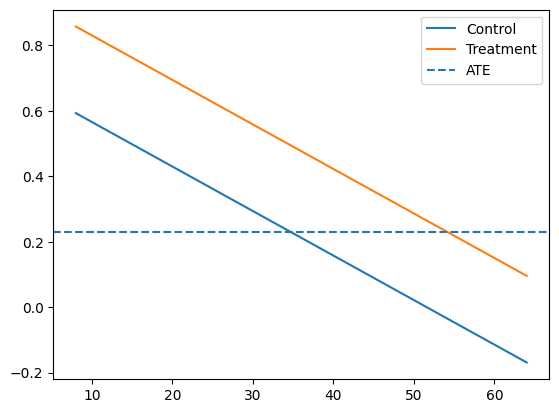

In [80]:
age_grid = np.linspace(df['age'].min(), df['age'].max(), 100)

pred_control = model.predict(np.column_stack((np.zeros_like(age_grid), age_grid)))
pred_treatment = model.predict(np.column_stack((np.ones_like(age_grid), age_grid)))
ATE = df[df['treatment_var'] == 1]['y'].mean() - df[df['treatment_var'] == 0]['y'].mean()

plt.plot(age_grid, pred_control, label='Control')
plt.plot(age_grid, pred_treatment, label='Treatment')

plt.axhline(y=ATE, linestyle='--', label='ATE')

plt.legend()
plt.show()

ATE overestimates at ages over 55 and underestimates for ages below 35. 

In [81]:
# Question 4

df['treatment_var'] = (df['transplant'] == 'treatment').astype(int)
df['treatment_age'] = df['treatment_var'] * df['age']

X = df[['treatment_var', 'age', 'treatment_age']]
y = df['y']

model = LinearRegression()
model.fit(X, y)

b0 = model.intercept_
b1 = model.coef_[0]
b2 = model.coef_[1]
b3 = model.coef_[2]

print('Intercept:', b0)
print('Treatment:', b1)
print('Age:', b2)
print('Treatment and Age:', b3)

Intercept: 0.35486517529945866
Treatment: 0.9077513885685893
Age: -0.005524257506973695
Treatment and Age: -0.014590638256855278


The interaction tells us the effect of transplant of age, if there is one. The coefficients shows us that transplant effect and age have a negative relationship. Overall, the pattern shows that as age increases, survival rate decreases. 

In [83]:
# Question 5

kf = KFold(n_splits=10, shuffle=True, random_state=42)
lr = LinearRegression()
mse1 = -cross_val_score(lr, df[['transplant_num']], df['y'], cv=kf, scoring='neg_mean_squared_error').mean()
mse2 = -cross_val_score(lr, df[['transplant_num', 'age']], df['y'], cv=kf, scoring='neg_mean_squared_error').mean()
mse3 = -cross_val_score(lr, df[['treatment_var', 'age', 'treatment_age']], df['y'], cv=kf, scoring='neg_mean_squared_error').mean()
print(f"MSE Model 1: {mse1:.4f}")
print(f"MSE Model 2: {mse2:.4f}")
print(f"MSE Model 3: {mse3:.4f}")

MSE Model 1: 0.1931
MSE Model 2: 0.1773
MSE Model 3: 0.1751


Model 3 has the lowest MSE, making it the most accurate. This shows that age is an important factor at play.

Question 6: Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?

The model implies that older people that need a transplant and lower priority and survival rates, which means that they are more likely to be denied for it. Also, it looks like the model uses binary outcomes to make predictions, but as discussed in the first question, this can lead to inconsistencies as it is hard to make very accurate predictions with just 0s and 1s. There are also more variables that come into play with transplants here that aren't considered.